Maximum classification accuracy of 62.5 % found in a window of a size 0.7 sec, and -1.1 sec before the beep


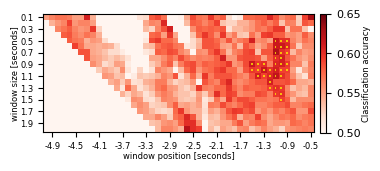

In [2]:
import numpy as np
import pandas as pd
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import scipy as sp
from datetime import datetime
import os

# Get the current date and time
current_datetime = datetime.now()
curr_datetime = str(current_datetime.strftime("%Y%m%d_%H%M%S"))

# Select 'classified_ie.mat' file
classified_ie = 'results/eeg_classified_ie.mat'
ie = sp.io.loadmat(classified_ie)
res_dir = os.path.split(classified_ie)
res_dir = res_dir[0]

# TFCE
def tfce_2d(data, H=2, E=0.5, dh=0.01):
    """
    Apply the TFCE (Threshold-Free Cluster Enhancement) algorithm to a 2D matrix.
    
    Parameters:
    - data: 2D numpy array of input data.
    - H: float, TFCE height exponent. H=2 is a default.
    - E: float, TFCE extent exponent. E=0.5 is a default.
    - dh: float, step size for height.
    
    Returns:
    - tfce_data: 2D numpy array of TFCE-enhanced data.
    """
    
    # Get the maximum data value
    max_value = np.max(data)

    # Initialize the output array
    tfce_data = np.zeros_like(data)

    s = [[0,1,0],
     [1,1,1],
     [0,1,0]]
    
    ind = 1
    # Iterate over possible heights
    for h in np.arange(0, max_value, dh):
        # Binarize the data at the current height
        binarized_data = data > h
        
        # Label the connected components
        labeled_data, num_features = ndimage.label(binarized_data, structure=s)
        
        # Calculate the size of each component
        component_sizes = ndimage.sum(binarized_data, labeled_data, range(1, num_features + 1))
        
        # Apply the TFCE formula
        for label_index, size in enumerate(component_sizes, start=1):
            tfce_data[labeled_data == label_index] += (h ** H) * (size ** E) * dh

        ind += 1
    
    return tfce_data

# Mask results outside the possible combinations of window sizes & possitions
lm = np.ones([20,26])
lt = np.triu(np.ones([20,20]), k=0)
mask_mat = np.append(lt,lm, axis=1)

# Classification accuracy on the original data
matrix = np.fliplr(ie['acc'])
matrix = matrix*mask_mat


# Classification accuracy on permuted data
perm_matrix = np.fliplr(ie['acc_perm'])
perm_matrix = perm_matrix*mask_mat[:,:,None]

# Apply TFCE to the original matrix
tfce_result = tfce_2d(matrix)

# Apply TFCE to the permuted matrix
n_perms = 5000
perm_tfce_max = np.zeros(n_perms)

for i in range(n_perms):
    tfce_perm = tfce_2d(perm_matrix[:,:,i])
    perm_tfce_max[i] = np.max(tfce_perm)

# Calculate p-values for the observed data
p_values = np.zeros((tfce_result.shape[0]*tfce_result.shape[1]))

for i, tfce_observed_value in enumerate(tfce_result.flatten()):
    p_values[i] = np.sum(perm_tfce_max >= tfce_observed_value)/n_perms

p_values = p_values.reshape(tfce_result.shape)
p_thr = 0.05

tfce_mask = p_values < p_thr

# Find the maximum value of classification accuracy
matrix_tfce_masked = matrix*tfce_mask
max_acc = np.max(matrix_tfce_masked)*100
index = np.unravel_index(np.argmax(matrix_tfce_masked), matrix_tfce_masked.shape)

n_cols = matrix_tfce_masked.shape[1]
n_rows = matrix_tfce_masked.shape[0]

wp = np.linspace(-4.9, -0.4, num=n_cols, endpoint=False).round(1)
ws = np.linspace(0.1, 2.1, num=n_rows, endpoint=False).round(1)

max_acc_wp = wp[index[1]]
max_acc_ws = ws[index[0]]

print(f'Maximum classification accuracy of {max_acc:.1f} % found in a window of a size {max_acc_ws:.1f} sec, and {max_acc_wp:.1f} sec before the beep')

# Plot TFCE results
figsize = (10/2.54, 5/2.54)  # Convert cm to inches for figsize
fig = plt.figure(figsize=figsize)

plt.imshow(matrix, cmap='Reds', vmin=0.5, vmax=0.65)
cbar = plt.colorbar(shrink=0.75, pad=0.02)
cbar.ax.yaxis.set_tick_params(labelsize=8)
cbar.set_label(label='Classification accuracy', fontsize=6, labelpad=1)
highlight_y, highlight_x = np.where(tfce_mask)

plt.scatter(highlight_x, highlight_y, color='yellow', marker='s', s=2, edgecolor='none', alpha=0.7)
y_ticks = np.arange(0, matrix.shape[0], 2)
y_ticks_num = 10
y_labels = np.linspace(0.1, 2.1, num=y_ticks_num, endpoint=False).round(decimals=1)
x_ticks = np.arange(1, matrix.shape[1], 1)
x_ticks_num = 46
x_ticks = x_ticks[::4]
x_labels = np.linspace(-0.5, -5.1, num=x_ticks_num, endpoint=False).round(decimals=2)
x_labels = x_labels[::4]
x_labels = np.flipud(x_labels)

plt.xlabel('window position [seconds]', fontsize=6, labelpad=1)
plt.xticks(x_ticks,x_labels, fontsize=6)
plt.yticks(y_ticks,y_labels, fontsize=6)
plt.ylabel('window size [seconds]', fontsize=6, labelpad=1)
plt.tight_layout()
plt.show()

#fig_file = os.path.join(res_dir,('tfce_acc.svg'))
#fig.savefig(fig_file, format='svg', bbox_inches='tight')
